In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [24]:
 def plot_data(file, skip, teff_min, teff_max, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)
    #print(df.columns)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    df_combined = pd.concat([df_combined, df], ignore_index=True)

    plt.scatter(df['pl_rade'], df['st_teff'], alpha=0.5, label=file)
    if 'pl_name' in df.columns:
        for i, txt in enumerate(df['pl_name']):
            plt.annotate(txt, (df['pl_rade'].iloc[i], df['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.legend()
    plt.grid(True)
    plt.show()

    data_for_plot_1 = df_combined[['pl_rade', 'st_teff']]

    file_1_len = len(df_combined)

    #print(f"File 1: {file1}\n{file_1_len} planets, Teff {teff_min1} - {teff_max1} K\n")


    avg_pl_rade = df_combined['pl_rade'].mean()
    median_pl_rade = df_combined['pl_rade'].median()

    # Plot histograms for 'pl_rade' column
    plt.figure(figsize=(12, 6))
    plt.hist(data_for_plot_1['pl_rade'], bins=20, alpha=0.5, label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    plt.axvline(avg_pl_rade, color='r', linestyle='dashed', linewidth=1, label=f'Mean radius: {avg_pl_rade:.2f}')
    plt.axvline(median_pl_rade, color='k', linestyle='dashed', linewidth=1, label=f'Median radius: {median_pl_rade:.2f}')
    plt.title('Histogram of Planetary Radius (pl_rade)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

    # # Plot histograms for 'st_teff' column
    # plt.figure(figsize=(12, 6))
    # plt.hist(data_for_plot_1['st_teff'], bins=20, alpha=0.5, label=str(f'{file1} {teff_min1}-{teff_max1}K'))
    # plt.title('Histogram of Stellar Effective Temperature (st_teff)')
    # plt.xlabel('Stellar Effective Temperature (K)')
    # plt.ylabel('Frequency')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

  


    return teff_min1, teff_max1, rad_min1, rad_max1, file_1_len, avg_pl_rade, median_pl_rade



#P-value of .05 is 2sigma, so this means that the chance that the sample is the same is 95%... or 5%???
#remove smaller planets to remove bias to smaller stars

KeyError: 'pl_name'


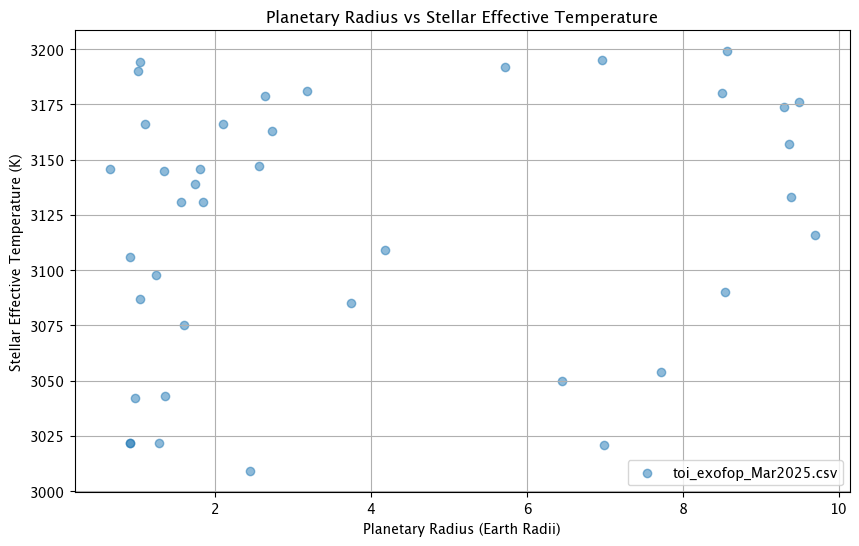

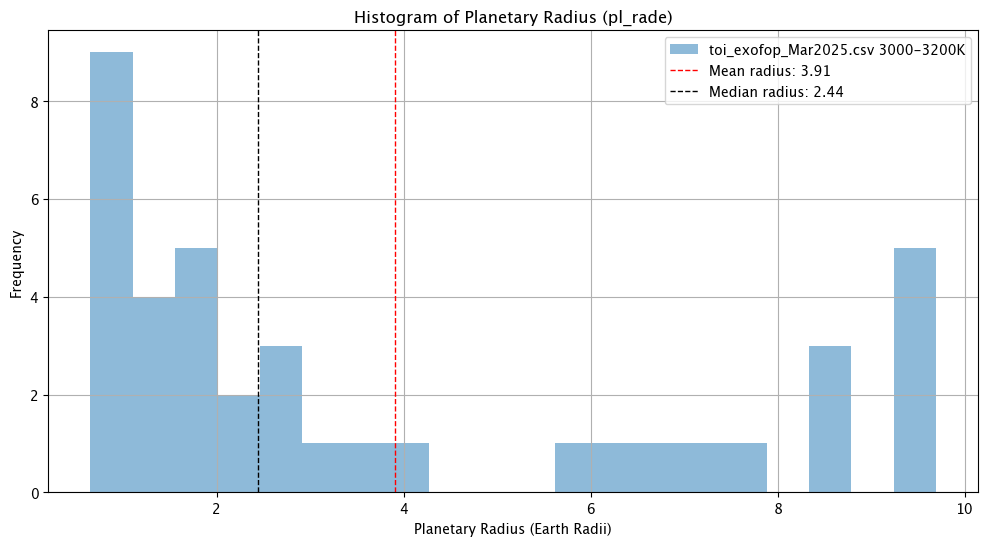

File: toi_exofop_Mar2025.csv
Number of planets: 39
Teff range: 3000 - 3200 K
Radius range: 0 - 10 Earth Radii

Average Planetary Radius: 3.9096456574514016
Median Planetary Radius: 2.442348


In [25]:
file1 = 'toi_exofop_Mar2025.csv'
skip1 = 0
teff_min1 = 3000
teff_max1 = 3200
rad_min1 = 0
rad_max1 = 10

teff_min1, teff_max1, rad_min1, rad_max1, file_1_len, avg_pl_rade, median_pl_rade = plot_data(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nRadius range: {rad_min1} - {rad_max1} Earth Radii\n")
print(f"Average Planetary Radius: {avg_pl_rade}")
print(f"Median Planetary Radius: {median_pl_rade}")

KeyError: 'pl_name'


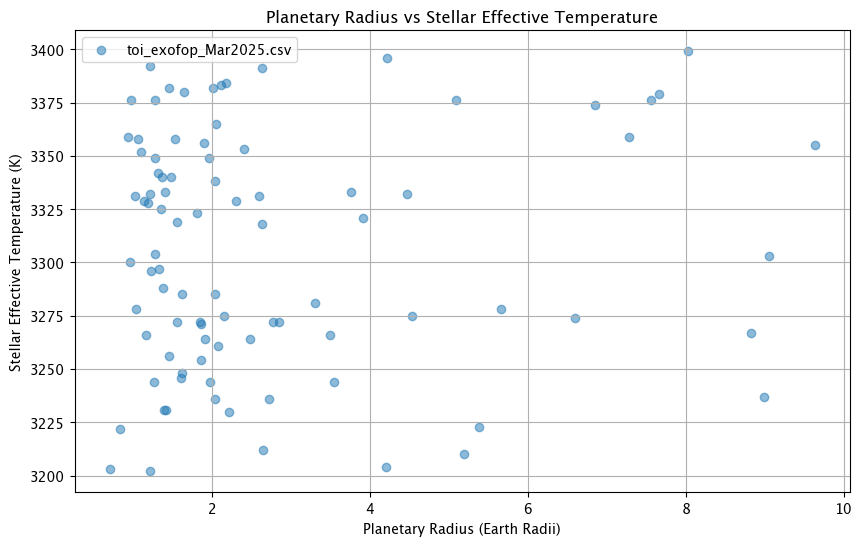

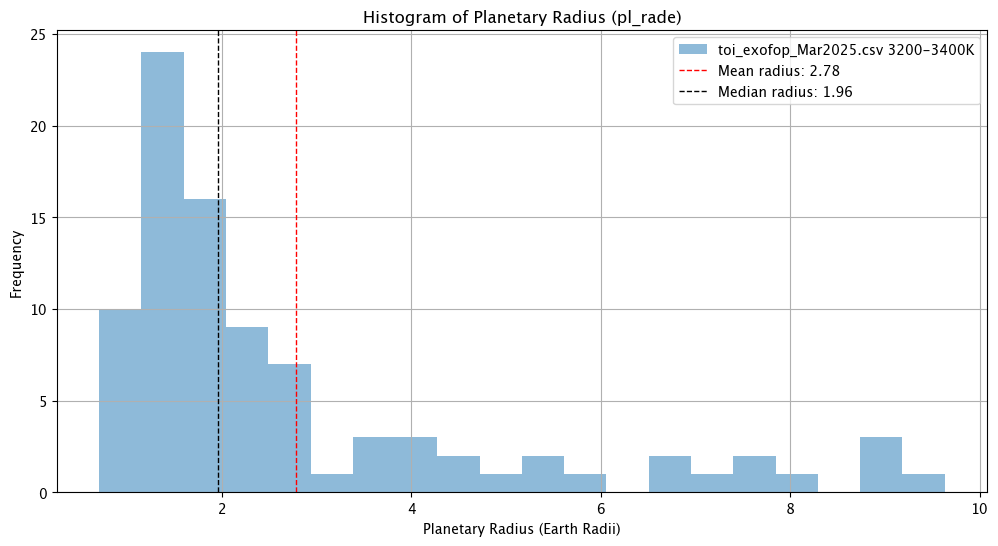

File: toi_exofop_Mar2025.csv
Number of planets: 89
Teff range: 3200 - 3400 K
Radius range: 0 - 10 Earth Radii

Average Planetary Radius: 2.784613347804429
Median Planetary Radius: 1.96023728527943


In [27]:
file1 = 'toi_exofop_Mar2025.csv'
skip1 = 0
teff_min1 = 3200
teff_max1 = 3400
rad_min1 = 0
rad_max1 = 10

teff_min1, teff_max1, rad_min1, rad_max1, file_1_len, avg_pl_rade, median_pl_rade = plot_data(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nRadius range: {rad_min1} - {rad_max1} Earth Radii\n")
print(f"Average Planetary Radius: {avg_pl_rade}")
print(f"Median Planetary Radius: {median_pl_rade}")

KeyError: 'pl_name'


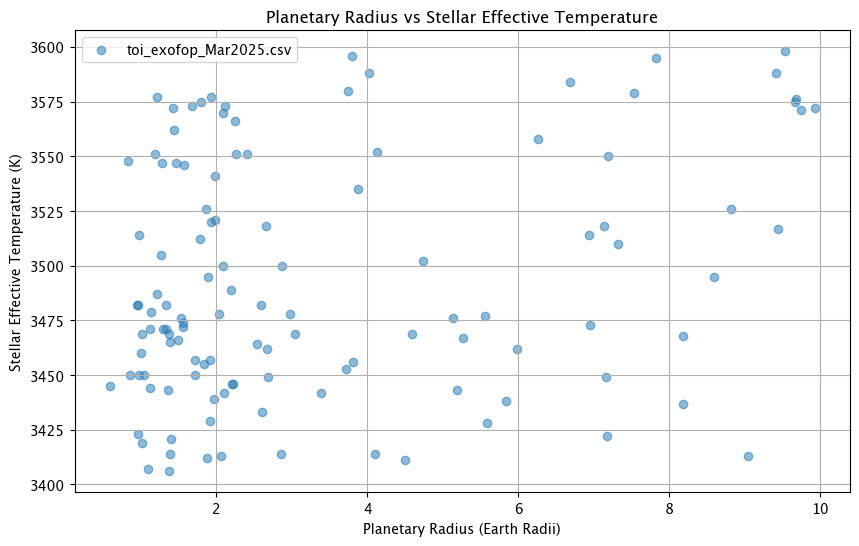

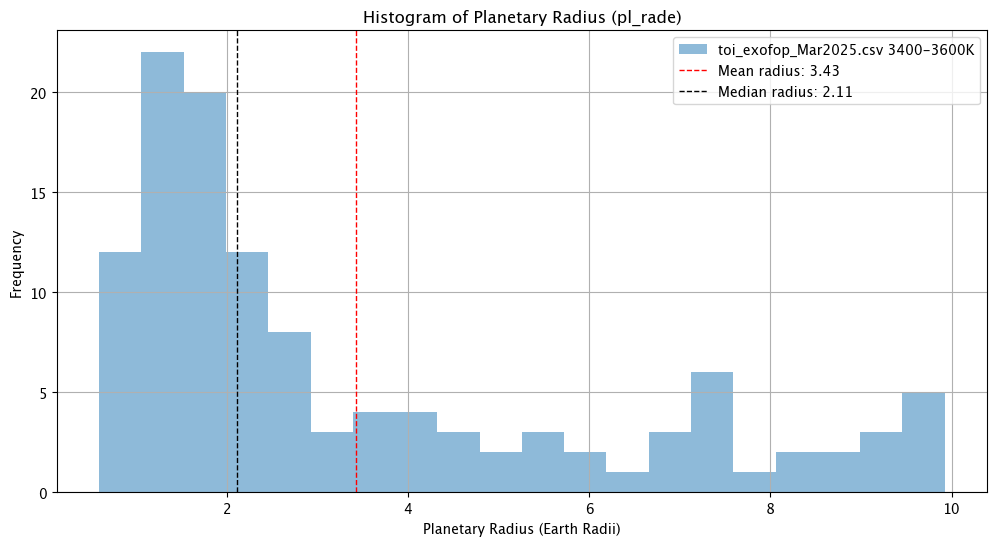

File: toi_exofop_Mar2025.csv
Number of planets: 118
Teff range: 3400 - 3600 K
Radius range: 0 - 10 Earth Radii

Average Planetary Radius: 3.429536873680263
Median Planetary Radius: 2.10801268925319


In [28]:
file1 = 'toi_exofop_Mar2025.csv'
skip1 = 0
teff_min1 = 3400
teff_max1 = 3600
rad_min1 = 0
rad_max1 = 10

teff_min1, teff_max1, rad_min1, rad_max1, file_1_len, avg_pl_rade, median_pl_rade = plot_data(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nRadius range: {rad_min1} - {rad_max1} Earth Radii\n")
print(f"Average Planetary Radius: {avg_pl_rade}")
print(f"Median Planetary Radius: {median_pl_rade}")

KeyError: 'pl_name'


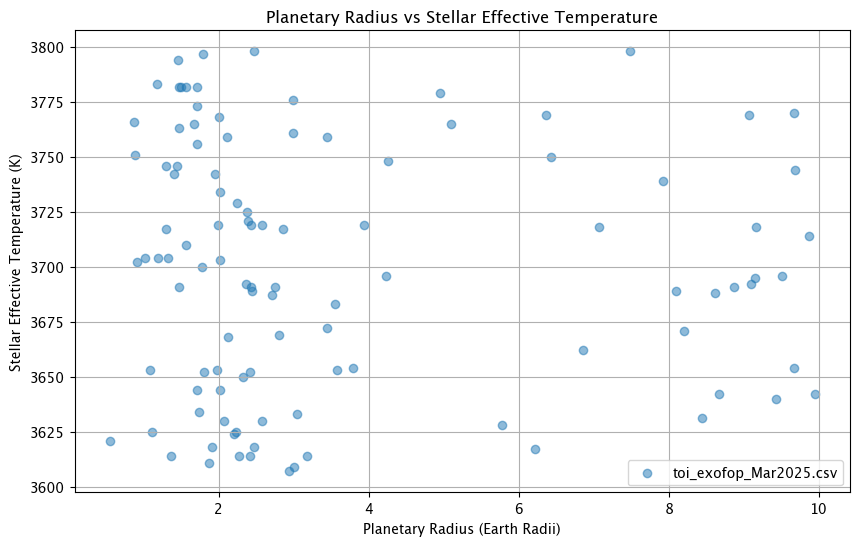

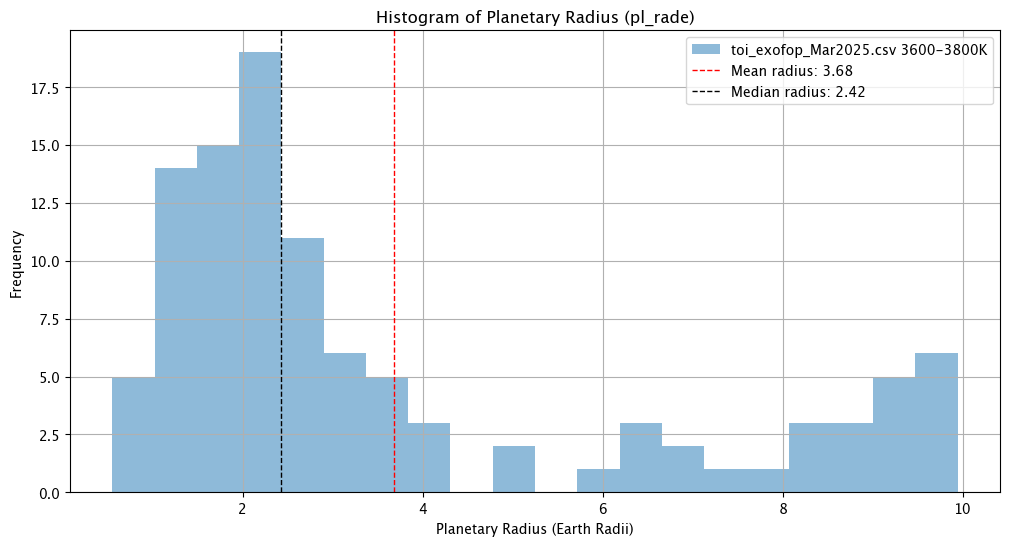

File: toi_exofop_Mar2025.csv
Number of planets: 105
Teff range: 3600 - 3800 K
Radius range: 0 - 10 Earth Radii

Average Planetary Radius: 3.682623695102568
Median Planetary Radius: 2.42419118730664


In [29]:
file1 = 'toi_exofop_Mar2025.csv'
skip1 = 0
teff_min1 = 3600
teff_max1 = 3800
rad_min1 = 0
rad_max1 = 10

teff_min1, teff_max1, rad_min1, rad_max1, file_1_len, avg_pl_rade, median_pl_rade = plot_data(file1, skip1, teff_min1, teff_max1, rad_min1, rad_max1)
print(f"File: {file1}\nNumber of planets: {file_1_len}\nTeff range: {teff_min1} - {teff_max1} K\nRadius range: {rad_min1} - {rad_max1} Earth Radii\n")
print(f"Average Planetary Radius: {avg_pl_rade}")
print(f"Median Planetary Radius: {median_pl_rade}")